In [31]:
%matplotlib widget
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.signal import savgol_filter, medfilt

In [32]:
logs_dir = Path('/home/erie/Tonometry/logs')
normal_limb_path = r'/home/erie/Tonometry/logs/sequence_20260304_173837.csv' 

In [33]:
def lvdt_csv_read(file_path):
    data = pd.read_csv(file_path, skiprows=1, header=None)
    time = data.iloc[:, 0].to_numpy()
    lvdt_voltage = data.iloc[:, 2].to_numpy()
    lvdt_disp = data.iloc[:, 3].to_numpy()
    motor_state = data.iloc[:, 3]

    t_max = time.max()
    time = time - time[0]  # Reset time to start from zero
    lvdt_disp = lvdt_disp - lvdt_disp[0]  # Reset displacement to start from zero

    return np.vstack((time, lvdt_disp)).T


In [34]:
nomarl_limb_data = lvdt_csv_read(normal_limb_path)

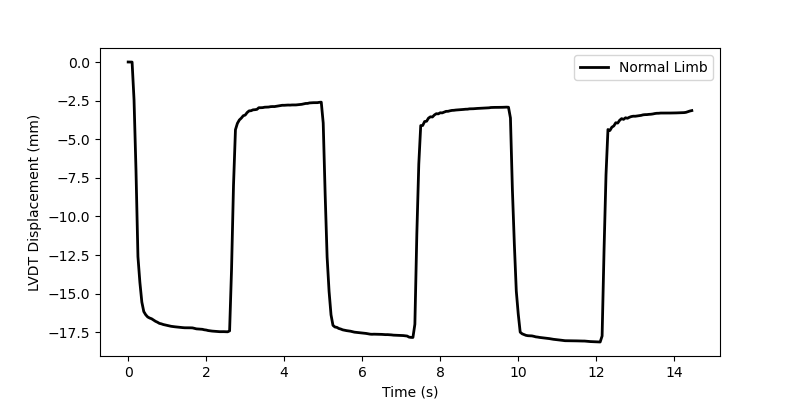

In [35]:
plt.figure(figsize=(8, 4))
lw = 2
plt.plot(nomarl_limb_data[:,0], nomarl_limb_data[:,1], color = 'black', linewidth = lw, label = 'Normal Limb')
# plt.ylim(-16,2)
plt.xlabel('Time (s)')
plt.ylabel('LVDT Displacement (mm)')
plt.legend()
# plt.savefig(f"Normal_vs_pressured_limb_long_indent.pdf", format="pdf", dpi=300, bbox_inches="tight")
plt.show()